# Analisis Hidrograf Banjir — GRRR (Google)
## Google Runoff Reanalysis & Reforecast + Analisis Frekuensi


**Sumber data:** Google Runoff Reanalysis & Reforecast (GRRR)
`gs://flood-forecasting/hydrologic_predictions/model_id_8583a5c2_v0/`

**Model:** LSTM berbasis multi-forcing (ERA5-Land + IMERG + CPC), dilatih pada data GRDC global

**Lisensi dataset:** CC-BY-4.0

**Metodologi:**
- Reanalysis harian GRRR (1980–2023)
- Identifikasi gauge_id HydroBasins untuk suatu DAS
- Analisis frekuensi: Log Pearson III / Gumbel / Log-Normal
- Hidrograf desain + export HEC-RAS
- Perbandingan return period GRRR vs built-in Google vs GEOGLOWS

**Referensi:**
- Nevo et al. (2024). *Nature*. doi:10.1038/s41586-024-07145-1
- Google Flood Forecasting: https://sites.research.google/gr/floodforecasting/

## 0. Instalasi & Import

In [ ]:
!pip install zarr xarray gcsfs scipy -q
print('Instalasi selesai')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 33.4 MB/s eta 0:00:00
Instalasi selesai


In [ ]:
import os
import datetime
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from scipy.stats import pearson3, gumbel_r, lognorm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi':120,'axes.grid':True,'grid.alpha':0.4})
print('Import OK')

Import OK


## 1. Koneksi ke Dataset GRRR (Google Cloud Storage)

Dataset GRRR tersimpan di Google Cloud Storage bucket publik:
`gs://flood-forecasting/hydrologic_predictions/model_id_8583a5c2_v0/`

Tiga komponen:
- **reanalysis** — streamflow harian 1980–2023 (>1 juta lokasi)
- **reforecast** — forecast 0–7 hari lead time, 2016–2022
- **return_periods** — threshold periode ulang 2, 5, 10, 20, 50, 100 tahun (sudah dihitung Google)

In [ ]:
import xarray as xr

BASE = 'gs://flood-forecasting/hydrologic_predictions/model_id_8583a5c2_v0/'

def open_zarr(path):
    """Buka dataset Zarr dari Google Cloud Storage (tanpa autentikasi)."""
    return xr.open_zarr(
        store=path,
        chunks=None,
        storage_options=dict(token='anon')
    )

print('Menghubungkan ke GRRR dataset ...')
reanalysis_ds     = open_zarr(f'{BASE}reanalysis/streamflow.zarr')
return_periods_ds = open_zarr(f'{BASE}return_periods.zarr')
outlets_ds        = open_zarr(f'{BASE}hybas_outlet_locations_UNOFFICIAL.zarr')

print(f'Reanalysis  : {dict(reanalysis_ds.sizes)}')
print(f'Return per. : {dict(return_periods_ds.sizes)}')
print(f'Outlets     : {dict(outlets_ds.sizes)}')
print()
print('Variabel return_periods:')
print(list(return_periods_ds.data_vars))

Menghubungkan ke GRRR dataset ...
Reanalysis  : {'gauge_id': 1031646, 'time': 16063}
Return per. : {'gauge_id': 1031646}
Outlets     : {'gauge_id': 1034083}

Variabel return_periods:
['return_period_10', 'return_period_100', 'return_period_15', 'return_period_2', 'return_period_20', 'return_period_200', 'return_period_25', 'return_period_5', 'return_period_50', 'return_period_7']


## 1b. Identifikasi Gauge ID untuk suatu DAS/SubDAS
GRRR menggunakan jaringan HydroBasins. Kita cari gauge_id yang outlet-nya
paling dekat dengan outlet Sungai yang *diketahui*.

In [ ]:
# Koordinat outlet DAS/SubDAS
LAT_OUTLET = 0.35
LON_OUTLET = 121.87
SEARCH_RADIUS = 0.1  # derajat radius pencarian awal

print(f'Mencari gauge terdekat dengan koordinat {LAT_OUTLET}N, {LON_OUTLET}E ...')
print('(proses loading ~1-2 menit untuk dataset 1M+ gauge)')

# Load semua koordinat outlet
outlets_df = outlets_ds.to_dataframe().reset_index()
print(f'Total gauge tersedia : {len(outlets_df):,}')
print(f'Kolom                : {list(outlets_df.columns)}')

Mencari gauge terdekat dengan koordinat 0.35N, 121.87E ...
(proses loading ~1-2 menit untuk dataset 1M+ gauge)
Total gauge tersedia : 1,034,083
Kolom                : ['gauge_id', 'latitude', 'longitude']


In [ ]:
# Filter gauge dalam radius pencarian
mask = (
    (outlets_df['latitude']  >= LAT_OUTLET - SEARCH_RADIUS) &
    (outlets_df['latitude']  <= LAT_OUTLET + SEARCH_RADIUS) &
    (outlets_df['longitude'] >= LON_OUTLET - SEARCH_RADIUS) &
    (outlets_df['longitude'] <= LON_OUTLET + SEARCH_RADIUS)
)
candidates = outlets_df[mask].copy()
print(f'Kandidat dalam radius {SEARCH_RADIUS}°: {len(candidates)}')

if len(candidates) > 0:
    # Hitung jarak Euclidean
    candidates['dist_deg'] = np.sqrt(
        (candidates['latitude']  - LAT_OUTLET)**2 +
        (candidates['longitude'] - LON_OUTLET)**2
    )
    top5 = candidates.nsmallest(5, 'dist_deg')[['gauge_id','latitude','longitude','dist_deg']]
    print()
    print('5 gauge terdekat:')
    print(top5.to_string(index=False))
    print()
    GAUGE_ID_NEAREST = top5.iloc[0]['gauge_id']
    print(f'Gauge terdekat: {GAUGE_ID_NEAREST}')
    print()
    print('PENTING: Update GAUGE_ID di bagian 1 dengan nilai ini,')
    print('lalu cek Q_max reanalysis — pilih yang paling masuk akal.')
else:
    print('Tidak ada kandidat. Perluas SEARCH_RADIUS.')

Kandidat dalam radius 0.1°: 4

5 gauge terdekat:
        gauge_id  latitude  longitude  dist_deg
hybas_5120033240  0.443750 121.906250  0.100514
hybas_5120033230  0.443750 121.918750  0.105668
hybas_5120033220  0.447917 121.943750  0.122584
hybas_5120033210  0.447917 121.947917  0.125135

Gauge terdekat: hybas_5120033240

PENTING: Update GAUGE_ID di bagian 1 dengan nilai ini,
lalu cek Q_max reanalysis — pilih yang paling masuk akal.


In [ ]:
# ================================================================
# UPDATE GAUGE_ID dengan hasil identifikasi di atas
# ================================================================

GAUGE_ID = GAUGE_ID_NEAREST   # otomatis dari hasil pencarian terdekat

START_YEAR = 1980                  # Tahun mulai analisis frekuensi

print(f'GAUGE_ID yang digunakan: {GAUGE_ID}')

GAUGE_ID yang digunakan: hybas_5120033240


## 2. Unduh Data Reanalysis GRRR

In [ ]:
print(f'Mengambil reanalysis untuk {GAUGE_ID} ...')

gauge_reanalysis  = reanalysis_ds.sel(gauge_id=GAUGE_ID).compute()
gauge_rp          = return_periods_ds.sel(gauge_id=GAUGE_ID).compute()

# Konversi ke DataFrame
df_daily = (
    gauge_reanalysis['streamflow']
    .to_dataframe()
    .reset_index()
    .set_index('time')[['streamflow']]
)
df_daily.columns = ['Q_sim']
df_daily.index   = pd.to_datetime(df_daily.index)
df_daily         = df_daily.sort_index()

# Return periods dari Google (sudah dihitung)
rp_vars = [v for v in return_periods_ds.data_vars if 'return_period' in v]
print()
print(f'Data reanalysis GRRR:')
print(f'  Rentang  : {df_daily.index.min().date()} s/d {df_daily.index.max().date()}')
print(f'  N hari   : {len(df_daily):,}')
print(f'  Q min    : {df_daily.Q_sim.min():.2f} m3/s')
print(f'  Q max    : {df_daily.Q_sim.max():.2f} m3/s')
print(f'  Q mean   : {df_daily.Q_sim.mean():.2f} m3/s')
print()
print('Return Periods (dari Google):')
for v in sorted(rp_vars):
    val = float(gauge_rp[v].values)
    print(f'  {v:<25}: {val:.1f} m3/s')

Mengambil reanalysis untuk hybas_5120033240 ...

Data reanalysis GRRR:
  Rentang  : 1980-01-01 s/d 2023-12-23
  N hari   : 16,063
  Q min    : 60.97 m3/s
  Q max    : 551.26 m3/s
  Q mean   : 182.65 m3/s

Return Periods (dari Google):
  return_period_10         : 449.2 m3/s
  return_period_100        : 547.4 m3/s
  return_period_15         : 467.7 m3/s
  return_period_2          : 358.9 m3/s
  return_period_20         : 480.4 m3/s
  return_period_200        : 575.0 m3/s
  return_period_25         : 490.1 m3/s
  return_period_5          : 415.0 m3/s
  return_period_50         : 519.2 m3/s
  return_period_7          : 432.1 m3/s


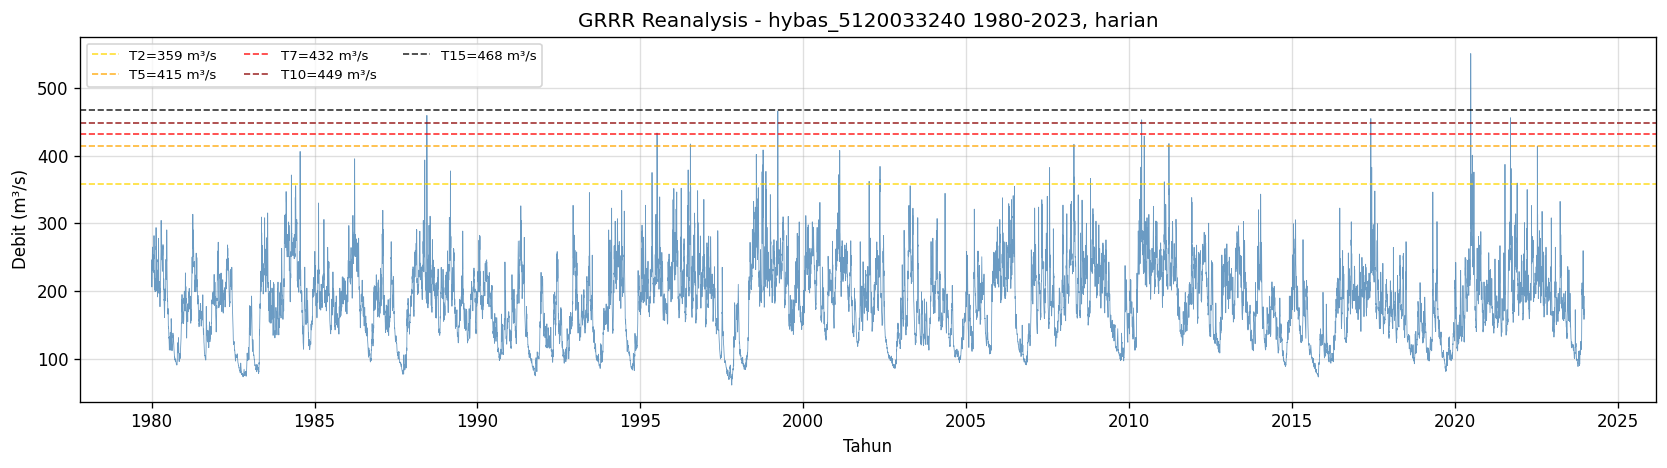

In [ ]:
# Plot time series overview
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_daily.index, df_daily['Q_sim'], lw=0.5, color='steelblue', alpha=0.8)

# Tambahkan garis return period Google
colors_rp = ['gold','orange','red','darkred','black']
rp_sorted = sorted(rp_vars, key=lambda x: int(''.join(filter(str.isdigit, x))))
for v, c in zip(rp_sorted[:5], colors_rp):
    val = float(gauge_rp[v].values)
    T   = ''.join(filter(str.isdigit, v))
    ax.axhline(val, color=c, ls='--', lw=1, alpha=0.8, label=f'T{T}={val:.0f} m³/s')

ax.set_title(f'GRRR Reanalysis - {GAUGE_ID} 1980-2023, harian')
ax.set_xlabel('Tahun'); ax.set_ylabel('Debit (m³/s)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(fontsize=8, loc='upper left', ncol=3)
plt.tight_layout()
plt.savefig('grrr_reanalysis_overview.png', dpi=150)
plt.show()

## 3. Filter Periode & Analisis Frekuensi

**Catatan penting tentang data GRRR:**
Data sudah berupa output model LSTM yang telah dilatih pada data observasi global (GRDC).
Tidak diperlukan bias correction seperti pada GEOGLOWS karena model sudah mengintegrasikan
koreksi implisit dalam proses training-nya.

Namun untuk DAS tanpa data training lokal (ungauged terhadap GRDC), tetap ada ketidakpastian.

In [ ]:
# Filter periode analisis
df = df_daily[f'{START_YEAR}-01-01':].copy()
print(f'Periode analisis: {df.index.min().date()} s/d {df.index.max().date()}')
print(f'N hari          : {len(df):,}')

# Annual Maximum Series
ams = df['Q_sim'].resample('YE').max().dropna()
cnt = df['Q_sim'].resample('YE').count()
ams = ams[cnt >= 300]

log_ams = np.log10(ams.values)

print()
print('=== ANNUAL MAXIMUM SERIES ===')
print(f'  N tahun  : {len(ams)}')
print(f'  Rentang  : {ams.index.year.min()} - {ams.index.year.max()}')
print(f'  Q min    : {ams.min():.1f} m3/s')
print(f'  Q max    : {ams.max():.1f} m3/s')
print(f'  Q mean   : {ams.mean():.1f} m3/s')
print(f'  Std dev  : {ams.std():.1f} m3/s')
print(f'  Cs (log) : {stats.skew(log_ams):.4f}')

Periode analisis: 1980-01-01 s/d 2023-12-23
N hari          : 16,063

=== ANNUAL MAXIMUM SERIES ===
  N tahun  : 44
  Rentang  : 1980 - 2023
  Q min    : 272.3 m3/s
  Q max    : 551.3 m3/s
  Q mean   : 364.3 m3/s
  Std dev  : 62.4 m3/s
  Cs (log) : 0.3915


In [ ]:
return_periods = [2, 5, 10, 25, 50, 100, 200, 500]
ex_probs       = [1 - 1/T for T in return_periods]
results        = {}

lp3_p = pearson3.fit(log_ams)
results['Log-Pearson III'] = {
    'Q'   : [10**pearson3.ppf(p,*lp3_p) for p in ex_probs],
    'KS_D': stats.kstest(log_ams,'pearson3',args=lp3_p).statistic,
    'KS_p': stats.kstest(log_ams,'pearson3',args=lp3_p).pvalue}

gum_p = gumbel_r.fit(ams.values)
results['Gumbel'] = {
    'Q'   : [gumbel_r.ppf(p,*gum_p) for p in ex_probs],
    'KS_D': stats.kstest(ams.values,'gumbel_r',args=gum_p).statistic,
    'KS_p': stats.kstest(ams.values,'gumbel_r',args=gum_p).pvalue}

ln_p = lognorm.fit(ams.values,floc=0)
results['Log-Normal'] = {
    'Q'   : [lognorm.ppf(p,*ln_p) for p in ex_probs],
    'KS_D': stats.kstest(ams.values,'lognorm',args=ln_p).statistic,
    'KS_p': stats.kstest(ams.values,'lognorm',args=ln_p).pvalue}

df_freq = pd.DataFrame(
    {d: r['Q'] for d, r in results.items()},
    index=[f'T={T}' for T in return_periods]
).round(1)

print('=== DEBIT RANCANGAN GRRR (m3/s) ===')
print(df_freq.to_string())
print()
print(f'{"Distribusi":<20} {"D-stat":>8} {"p-value":>10} {"Keputusan":>10}')
print('-'*53)
for d, r in results.items():
    ok = 'DITERIMA' if r['KS_p'] > 0.05 else 'DITOLAK'
    print(f'{d:<20} {r["KS_D"]:>8.4f} {r["KS_p"]:>10.4f} {ok:>10}')

best = max(results, key=lambda k: results[k]['KS_p'])
print(f'\nDistribusi terpilih: {best}  (p={results[best]["KS_p"]:.4f})')

=== DEBIT RANCANGAN GRRR (m3/s) ===
       Log-Pearson III  Gumbel  Log-Normal
T=2              351.5   353.6       359.4
T=5              409.8   408.7       412.5
T=10             450.0   445.2       443.3
T=25             502.5   491.3       478.8
T=50             542.8   525.6       503.1
T=100            584.2   559.5       526.1
T=200            627.1   593.4       548.1
T=500            686.3   638.0       575.9

Distribusi             D-stat    p-value  Keputusan
-----------------------------------------------------
Log-Pearson III        0.1068     0.6579   DITERIMA
Gumbel                 0.1099     0.6225   DITERIMA
Log-Normal             0.1180     0.5341   DITERIMA

Distribusi terpilih: Log-Pearson III  (p=0.6579)


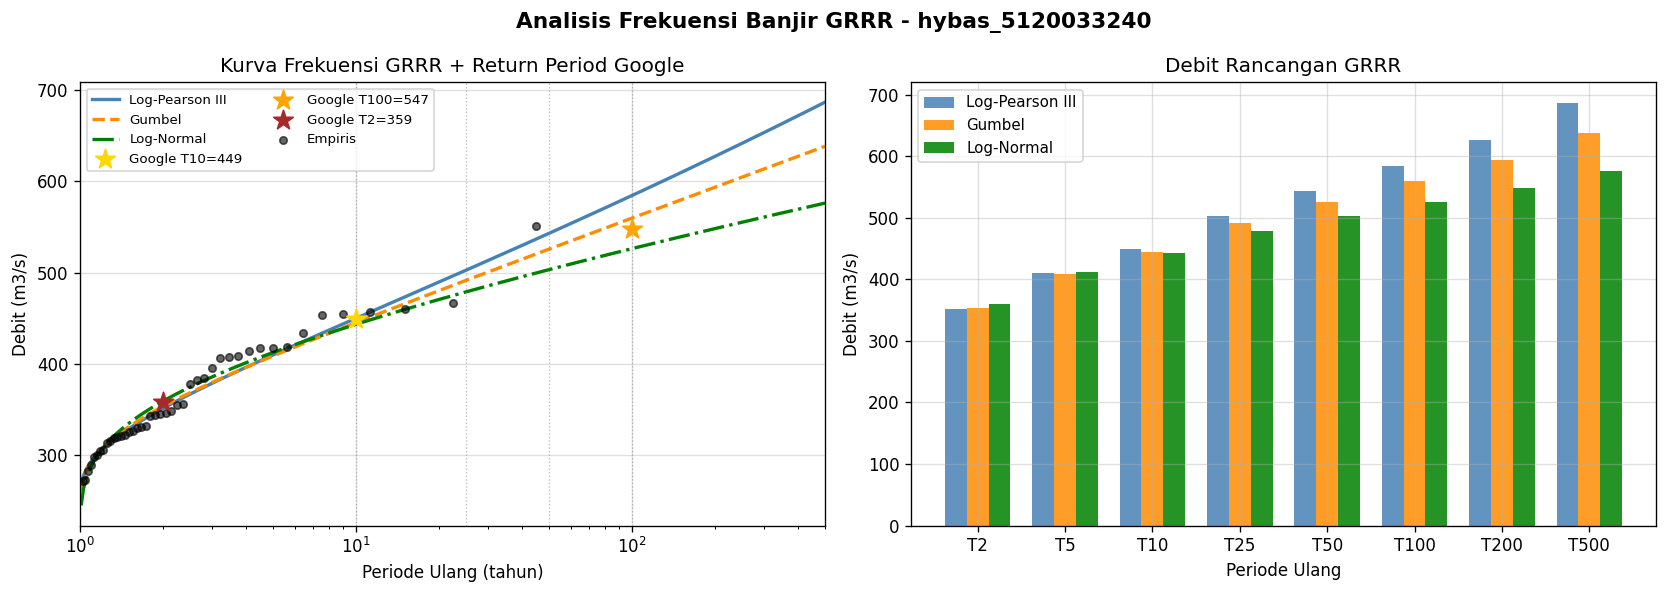

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
cols = {'Log-Pearson III':'steelblue','Gumbel':'darkorange','Log-Normal':'green'}
lss  = {'Log-Pearson III':'-','Gumbel':'--','Log-Normal':'-.'}

ax = axes[0]
Ts = np.logspace(np.log10(1.01), np.log10(500), 300)
ps = [1-1/T for T in Ts]
for dist in results:
    if dist=='Log-Pearson III': qs=[10**pearson3.ppf(p,*lp3_p) for p in ps]
    elif dist=='Gumbel'       : qs=[gumbel_r.ppf(p,*gum_p) for p in ps]
    else                      : qs=[lognorm.ppf(p,*ln_p) for p in ps]
    ax.semilogx(Ts,qs,lw=2,label=dist,color=cols[dist],linestyle=lss[dist])

# Return periods dari Google (titik referensi)
rp_T_map = {'2':'2','5':'5','10':'10','20':'20','50':'50','100':'100'}
for v, c in zip(sorted(rp_vars)[:5], ['gold','orange','red','brown','black']):
    T_num = int(''.join(filter(str.isdigit, v)))
    val   = float(gauge_rp[v].values)
    if T_num in return_periods:
        ax.scatter([T_num],[val],marker='*',s=150,color=c,zorder=6,
                   label=f'Google T{T_num}={val:.0f}')

ams_s=np.sort(ams.values); n=len(ams_s)
T_emp=(n+1)/(n+1-np.arange(1,n+1))
ax.scatter(T_emp,ams_s,c='black',zorder=5,s=20,label='Empiris',alpha=0.6)
for T in [10,25,50,100]: ax.axvline(T,color='gray',lw=0.8,ls=':',alpha=0.5)
ax.set_xlabel('Periode Ulang (tahun)'); ax.set_ylabel('Debit (m3/s)')
ax.set_title('Kurva Frekuensi GRRR + Return Period Google')
ax.legend(fontsize=8,ncol=2); ax.set_xlim([1,500])

ax = axes[1]
x=np.arange(len(return_periods))
for i,(d,r) in enumerate(results.items()):
    ax.bar(x+(i-1)*0.25,r['Q'],0.25,label=d,color=list(cols.values())[i],alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([f'T{T}' for T in return_periods])
ax.set_xlabel('Periode Ulang'); ax.set_ylabel('Debit (m3/s)')
ax.set_title('Debit Rancangan GRRR'); ax.legend(fontsize=9)
plt.suptitle(f'Analisis Frekuensi Banjir GRRR - {GAUGE_ID}',fontsize=13,fontweight='bold')
plt.tight_layout(); plt.savefig('grrr_freq_analysis.png',dpi=150); plt.show()

## 4. Hidrograf Desain dari GRRR

In [ ]:
def find_peaks(s, n=5, gap_days=30):
    pks = []
    for idx in s.sort_values(ascending=False).index:
        if not pks or all(abs((idx-p).days) >= gap_days for p in pks):
            pks.append(idx)
        if len(pks) >= n:
            break
    return pks

def get_event(s, pk, before=7, after=21):
    ev = s[pk-pd.Timedelta(days=before):pk+pd.Timedelta(days=after)].copy()
    ev.index = (ev.index - ev.index[0]).days
    return ev

top5 = find_peaks(df['Q_sim'])
print('Top 5 Event Banjir GRRR:')
print(f'{"No":>3}  {"Tanggal":>12}  {"Q_max (m3/s)":>14}')
print('-'*35)
for i, pk in enumerate(top5):
    print(f'{i+1:>3}  {str(pk.date()):>12}  {df.loc[pk,"Q_sim"]:>14.1f}')

Top 5 Event Banjir GRRR:
 No       Tanggal    Q_max (m3/s)
-----------------------------------
  1    2020-06-27           551.3
  2    1999-03-22           466.2
  3    1988-06-13           459.8
  4    2021-09-16           456.3
  5    2017-06-03           455.1


In [ ]:
T_design = 100  # ganti: 2, 5, 10, 25, 50, 100, 200, 500

T_idx    = return_periods.index(T_design)
Q_design = results[best]['Q'][T_idx]
tmpl     = get_event(df['Q_sim'], top5[0])
scale    = Q_design / tmpl.max()
dh       = (tmpl * scale).clip(lower=0)

print(f'Distribusi  : {best}')
print(f'Q rancangan T{T_design}: {Q_design:.1f} m3/s')
print(f'Scale factor: {scale:.3f}')
print(f'Qpeak desain: {dh.max():.1f} m3/s')

Distribusi  : Log-Pearson III
Q rancangan T100: 584.2 m3/s
Scale factor: 1.060
Qpeak desain: 584.2 m3/s


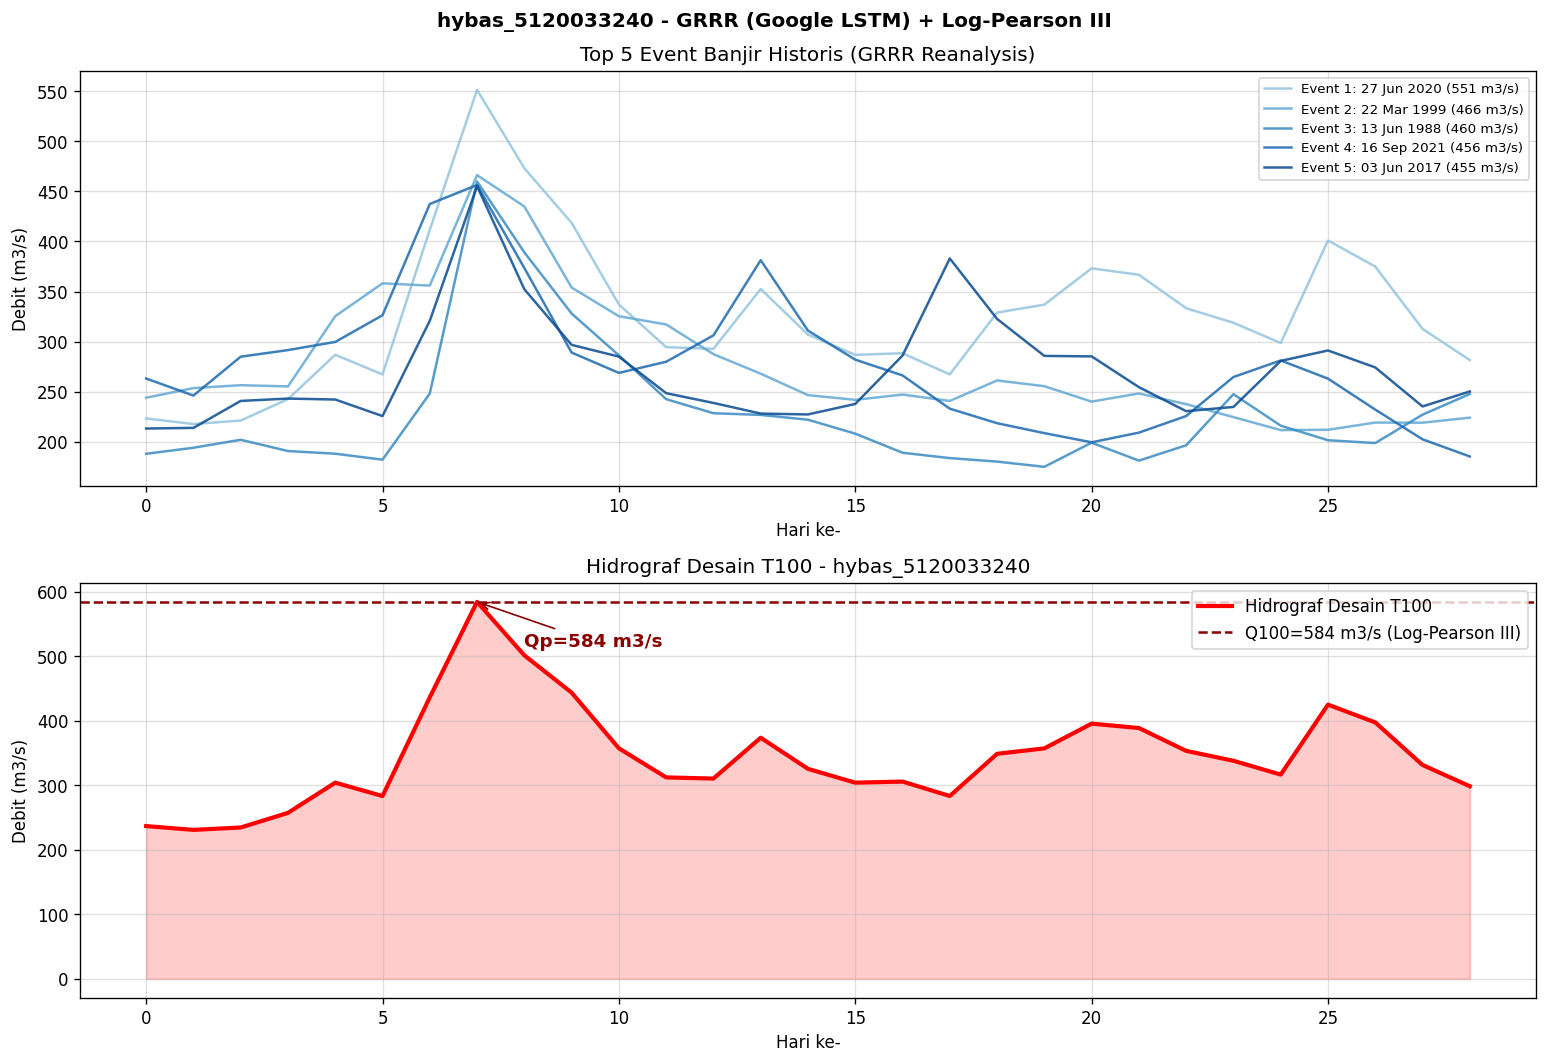

In [ ]:
fig, axes = plt.subplots(2,1,figsize=(13,9))
cm=plt.cm.Blues(np.linspace(0.4,0.9,5))
ax=axes[0]
for i,pk in enumerate(top5):
    ev=get_event(df['Q_sim'],pk)
    ax.plot(ev.index,ev.values,lw=1.5,color=cm[i],alpha=0.85,
            label=f'Event {i+1}: {pk.strftime("%d %b %Y")} ({df.loc[pk,"Q_sim"]:.0f} m3/s)')
ax.set_xlabel('Hari ke-'); ax.set_ylabel('Debit (m3/s)')
ax.set_title('Top 5 Event Banjir Historis (GRRR Reanalysis)'); ax.legend(fontsize=8)
ax=axes[1]
ax.fill_between(dh.index,dh.values,alpha=0.2,color='red')
ax.plot(dh.index,dh.values,lw=2.5,color='red',label=f'Hidrograf Desain T{T_design}')
ax.axhline(Q_design,color='darkred',ls='--',lw=1.5,
           label=f'Q{T_design}={Q_design:.0f} m3/s ({best})')
pk_d=dh.idxmax()
ax.annotate(f'Qp={dh.max():.0f} m3/s',xy=(pk_d,dh.max()),
    xytext=(pk_d+1,dh.max()*0.88),
    arrowprops=dict(arrowstyle='->',color='darkred'),
    fontsize=11,color='darkred',fontweight='bold')
ax.set_xlabel('Hari ke-'); ax.set_ylabel('Debit (m3/s)')
ax.set_title(f'Hidrograf Desain T{T_design} - {GAUGE_ID}')
ax.legend()
plt.suptitle(f'{GAUGE_ID} - GRRR (Google LSTM) + {best}',fontweight='bold')
plt.tight_layout(); plt.savefig(f'grrr_hydrograph_T{T_design}.png',dpi=150); plt.show()

## 5. Export

In [ ]:
# CSV hidrograf desain
pd.DataFrame({
    'time_days': dh.index,
    'Q_m3s'    : dh.values.round(3)
}).to_csv(f'grrr_hydrograph_T{T_design}_{GAUGE_ID}.csv', index=False)
print(f'CSV: grrr_hydrograph_T{T_design}_{GAUGE_ID}.csv')

# HEC-RAS
lines = [
    f'# Hidrograf Desain T{T_design} tahun - {GAUGE_ID}',
    f'# Sumber data   : GRRR (Google Runoff Reanalysis & Reforecast)',
    f'# Model         : Google LSTM (Nevo et al. 2024, Nature)',
    f'# Distribusi    : {best}',
    f'# Q_peak        : {Q_design:.0f} m3/s',
    f'# Gauge ID      : {GAUGE_ID}',
    f'# Lisensi data  : CC-BY-4.0',
    '# Time(day)  Flow(m3/s)'
]
for t, q in zip(dh.index, dh.values):
    lines.append(f'{t:10.1f}  {q:10.3f}')
with open(f'HECRAS_GRRR_T{T_design}_{GAUGE_ID}.txt', 'w') as f:
    f.write('\n'.join(lines))
print(f'HEC-RAS: HECRAS_GRRR_T{T_design}_{GAUGE_ID}.txt')

# Tabel semua T
df_freq.to_csv(f'grrr_debit_rancangan_{GAUGE_ID}.csv')
print(f'Tabel  : grrr_debit_rancangan_{GAUGE_ID}.csv')

CSV: grrr_hydrograph_T100_hybas_5120033240.csv
HEC-RAS: HECRAS_GRRR_T100_hybas_5120033240.txt
Tabel  : grrr_debit_rancangan_hybas_5120033240.csv


## 8. Catatan Metodologis

---

**Data Debit**

Data debit harian diperoleh dari GRRR (*Google Runoff Reanalysis & Reforecast*),
produk model hidrologi LSTM milik Google yang dilatih pada data observasi debit global
dari GRDC (*Global Runoff Data Centre*) dan digerakkan oleh multi-forcing meteorologi
(ERA5-Land, NASA IMERG, NOAA CPC). Data mencakup periode 1980–2023 dalam resolusi harian,
diakses dari Google Cloud Storage (`gs://flood-forecasting/...`) dengan lisensi CC-BY-4.0.
Gauge ID yang digunakan adalah [GAUGE_ID], merepresentasikan outlet sub-basin HydroBasins
terdekat dengan muara Sungai Randangan, Kabupaten Pohuwato, Gorontalo.

**Analisis Frekuensi**

Annual Maximum Series (AMS) periode [START_YEAR]–2023 dianalisis menggunakan
Log-Pearson III, Gumbel EV1, dan Log-Normal 2P. Distribusi terpilih berdasarkan
uji Kolmogorov-Smirnov (α = 0,05).

**Referensi**
- Nevo, S., et al. (2024). Flood forecasting with machine learning models in an operational
  framework. *Nature*. doi:10.1038/s41586-024-07145-1
- GRRR Dataset. CC-BY-4.0. https://sites.research.google/gr/floodforecasting/resources/

---